# Importing Data from [Natural Earth](https://www.naturalearthdata.com) with [rnaturalearth](https://cran.r-project.org/web/packages/rnaturalearth/index.html) and [rnaturalearthdata](https://cran.r-project.org/web/packages/rnaturalearthdata/index.html)
### by [Kate Vavra-Musser](https://vavramusser.github.io) for the [R Spatial Notebook Series](https://vavramusser.github.io/r-spatial)

## Introduction
[Natural Earth](https://www.naturalearthdata.com) is a public domain map dataset available at multiple scales, featuring a wide variety of cultural and physical geographic data. The [rnaturalearth](https://cran.r-project.org/web/packages/rnaturalearth/index.html) and [rnaturalearthdata](https://cran.r-project.org/web/packages/rnaturalearthdata/index.html) R packages simplify the process of accessing, downloading, and using these datasets directly within R. These datasets are particularly valuable for social sciences research involving spatial data analysis due to their compatibility with R's spatial data tools.

### Notebook Goals
In this notebook, we will explore how to use [rnaturalearth](https://cran.r-project.org/web/packages/rnaturalearth/index.html) and [rnaturalearthdata](https://cran.r-project.org/web/packages/rnaturalearthdata/index.html) to import data from Natural Earth. We will focus on reviewing available datasets, downloading them, and saving the data for further analysis. By the end of this notebook, you will have a workflow to efficiently access and visualize Natural Earth data, including cultural and physical features such as country and boundary polygons.

### ✨ Prerequisites ✨
* Complete [Introduciton to Natural Earth](https://platform.i-guide.io/notebooks/924c7ca6-3d12-4a80-ab4d-814cc80f7f79)
* Complete [Introduction to sf: Reading, Writing, and Inspecting Vector Data](https://platform.i-guide.io/notebooks/9968babe-22e4-4c3d-98e2-d8b45e9672cd)

### Notebook Overview
1. Setup
2. Explore Available Data from Natural Earth
3. Download and Save Data from Natural Earth

## 1. Setup
This notebook requires the following R packages and functions.

#### Required Packages

[**rnaturalearth**](https://cran.r-project.org/web/packages/rnaturalearth/index.html) · World Map Data from [Natural Earth](https://www.naturalearthdata.com) · Facilitates mapping by making natural earth map data from [Natural Earth](https://www.naturalearthdata.com) more easily available to R users · This notebook uses the folloing functions from *rnationalearth*.

* [*ne_countries*](https://rdrr.io/cran/rnaturalearth/man/ne_countries.html) · get natural earth world country polygons
* [*ne_download*](https://rdrr.io/cran/rnaturalearth/man/ne_download.html) · download data from Natural Earth and (optionally) read into R
* [*ne_find_vector_data*](https://rdrr.io/cran/rnaturalearth/man/ne_find_vector_data.html) · return a dataframe of available vector layers on Natural Earth

[**rnaturalearthdata**](https://cran.r-project.org/web/packages/rnaturalearthdata/index.html) · World Vector Map Data from [Natural Earth](https://www.naturalearthdata.com) Used in [rnaturalearth](https://cran.r-project.org/web/packages/rnaturalearth/index.html) · Vector map data from [Natural Earth](https://www.naturalearthdata.com) - Access functions are provided in the accompanying package [rnaturalearth](https://cran.r-project.org/web/packages/rnaturalearth/index.html)

[**sf**](https://cran.r-project.org/web/packages/sf/index.html) · Support for [simple features](https://r-spatial.github.io/sf/articles/sf1.html), a standardized way to encode spatial vector data - Binds to [*GDAL*](https://gdal.org/en/stable) for reading and writing data, to [*GEOS*](https://libgeos.org) for geometrical operations, and to [*PROJ*](https://proj.org/en/stable) for projection conversions and datum transformations - Uses by default the [*s2*](https://cran.r-project.org/web/packages/s2/index.html) package for spherical geometry operations on ellipsoidal (long/lat) coordinates · This notebook uses the following functions from *sf*.

* [*st_geometry*](https://rdrr.io/cran/sf/man/st_geometry.html) · get, set, replace or rename geometry from an sf object
* [*st_write*](https://rdrr.io/cran/sf/man/st_write.html) · write simple features object to file or database

### 1a. Install and Load Required Packages
If you have not already installed the required packages, uncomment and run the code below:

In [1]:
# install.packages(c("rnaturalearth", "rnaturalearthr", "sf"))

Load the packages into your workspace.

In [2]:
library(rnaturalearth)
library(rnaturalearthdata)
library(sf)

Support for Spatial objects (`sp`) will be deprecated in {rnaturalearth} and will be removed in a future release of the package. Please use `sf` objects with {rnaturalearth}. For example: `ne_download(returnclass = 'sf')`


Attaching package: 'rnaturalearthdata'


The following object is masked from 'package:rnaturalearth':

    countries110


Linking to GEOS 3.9.1, GDAL 3.2.1, PROJ 7.2.1; sf_use_s2() is TRUE



## 2. Explore Available Data from Natural Earth

Natural Earth provides datasets across three scales:

* Small scale (1:110m): Best for global or continental-scale analysis.
* Medium scale (1:50m): Useful for regional or country-level analysis.
* Large scale (1:10m): Provides the most detailed data, suitable for local-level analysis.

The [*ne_find_vector_data*](https://rdrr.io/cran/rnaturalearth/man/ne_find_vector_data.html) function helps you explore available data from [Natural Earth](https://www.naturalearthdata.com) based on scale and category.  The function *checks the Natural Earth Github repository for current vector layers and provides the file name required in the type argument of ne_download*. 

### 2a. Review the List of Cultural Data

Below, we review the available cultural data, which includes datasets such as administrative boundaries, populated places, and other human-related geographic features.   For this exercise, we will limit our search to only "cultural" data.

The purpose of this initial process is to explore what data is available and also identify the keywords for the layers we are interested in.  We will use the keywords in later functions to tell Natural Earth exactly what data we want to export.

In [3]:
# list of small scale cultural data (1:110 meters)
ne_find_vector_data(category = "cultural")

layer,scale
<chr>,<dbl>
admin_0_boundary_lines_land,110
admin_0_countries,110
admin_0_countries_lakes,110
admin_0_map_units,110
admin_0_pacific_groupings,110
admin_0_scale_rank,110
admin_0_sovereignty,110
admin_0_tiny_countries,110
admin_1_states_provinces,110


The function returns a list of 14 available cultural vector datasets.  Note that all the returned data is at the 1:110 (small) scale - this is the default scale for the function, but we can change the scale to 1:50 (medium) or 1:10 (large).  Below we slightly change our function call to search for only cultural vector data at scale 1:50 (medium).

In [4]:
# list of medium scale cultural data (1:50 meters)
ne_find_vector_data(category = "cultural", scale = 50)

layer,scale
<chr>,<dbl>
admin_0_boundary_lines_disputed_areas,50
admin_0_boundary_lines_land,50
admin_0_boundary_lines_maritime_indicator,50
admin_0_boundary_lines_maritime_indicator_chn,50
admin_0_boundary_map_units,50
admin_0_breakaway_disputed_areas,50
admin_0_countries,50
admin_0_countries_lakes,50
admin_0_map_subunits,50


Finally, let's also check out what cultural data is available at the 1:10 (large) scale.

In [5]:
# list of large scale cultural data (1:10 meters)
ne_find_vector_data(category = "cultural", scale = 10)

layer,scale
<chr>,<dbl>
admin_0_antarctic_claim_limit_lines,10
admin_0_antarctic_claims,10
admin_0_boundary_lines_disputed_areas,10
admin_0_boundary_lines_land,10
admin_0_boundary_lines_map_units,10
admin_0_boundary_lines_maritime_indicator,10
admin_0_boundary_lines_maritime_indicator_chn,10
admin_0_countries,10
admin_0_countries_arg,10


These commands display lists of available vector datasets, allowing you to browse the options and select datasets relevant to your analysis.  Once you've identified the datasets of interest, you can download them using functions in the next section.

## 3. Download and Save Data from Natural Earth

After identifying relevant datasets, you can download and visualize them using the [*ne_countries*](https://rdrr.io/cran/rnaturalearth/man/ne_countries.html) function for global country boundaries, [*ne_coastline*](https://rdrr.io/cran/rnaturalearth/man/ne_coastline.html) for global coastlines, and [*ne_download*](https://rdrr.io/cran/rnaturalearth/man/ne_download.html) for all other datasets.

### 3a. United States Boundary Polygons

As an example, we will download and visualize boundary polygons for the United States.  To do this, we will use the *ne_countries* function and specify that we only want the border of the United States of America.

In [6]:
# United States State Boundaries (polygons)
usa_boundary <- ne_countries(country = "United States of America")

Warning message:
"The `returnclass` argument of `ne_download()` sp as of rnaturalearth 1.0.0.
i Please use `sf` objects with {rnaturalearth}, support for Spatial objects
  (sp) will be removed in a future release of the package."


Let's take a look at the structure of the *usa_boundary* object.

In [7]:
usa_boundary

Registered S3 method overwritten by 'geojsonsf':
  method        from   
  print.geojson geojson



An object of class "SpatialPolygonsDataFrame"
Slot "data":
       featurecla scalerank labelrank               sovereignt sov_a3 adm0_dif
5 Admin-0 country         1         2 United States of America    US1        1
  level    type tlc                    admin adm0_a3 geou_dif
5     2 Country   1 United States of America     USA        0
                   geounit gu_a3 su_dif       subunit su_a3 brk_diff
5 United States of America   USA      0 United States   USA        0
                      name     name_long brk_a3      brk_name brk_group abbrev
5 United States of America United States    USA United States      <NA> U.S.A.
  postal                formal_en formal_fr    name_ciawf note_adm0 note_brk
5     US United States of America      <NA> United States      <NA>     <NA>
                 name_sort name_alt mapcolor7 mapcolor8 mapcolor9 mapcolor13
5 United States of America     <NA>         4         5         1          1
    pop_est pop_rank pop_year   gdp_md gdp_year        

In [9]:
usa_boundary <- st_as_sf(usa_boundary)

The *usa_boundary* object is an sf object with one row (representing the single country in the data - the United States) and 169 feature columns.  Recall that we can work with sf objects similar to the way we work with dataframes in R but sf objects also have special properties specific to spatial data.

Let's quickly map the data using R's native *plot* function.  We will pass the geometry of the *usa_boundary* object to the *plot* function using the *st_geometry* function from the ***sf*** package.

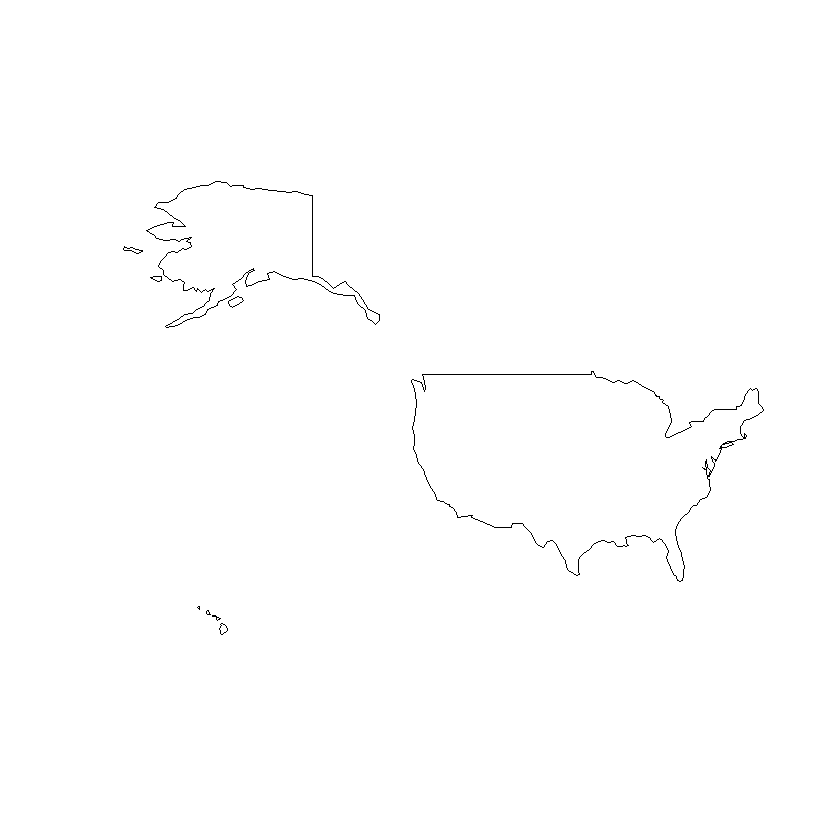

In [11]:
# plot the boundaries
plot(st_geometry(usa_boundary))

We can see that our downloaded data is a simple border of the entire United States of America including Alaska and Hawaii.

Finally, let's save our data locally as a shapefile so we can load it into other workflows and notebooks.  Prior to saving the data we need to remove a couple of memory-intensive columns including the population estimate (*pop_est*) and Natural Earth identification code (*ne_id*) columns.  These columns were identified during the development process of this notebook as roadblocks to saving the *usa_boundary* file in the next step.  If you are working with your own data, or a different extraction from Natural Earth, your experience and process may be different.

In [12]:
# simplify the dataset by removing memory-intensive columns
usa_boundary <- usa_boundary[, !names(usa_boundary) %in% c("pop_est", "ne_id")]

We'll save the *usa_boundary* object as a shapefile using the *st_write* function from the ***sf*** package.

In [13]:
# write the usa_boundaries shapefile
st_write(usa_boundary, "usa_boundary.shp", driver = "ESRI Shapefile", delete_dsn = T)

Warning message in CPL_write_ogr(obj, dsn, layer, driver, as.character(dataset_options), :
"GDAL Error 1: usa_boundary.shp does not appear to be a file or directory."


Deleting source `usa_boundary.shp' failed
Writing layer `usa_boundary' to data source 
  `usa_boundary.shp' using driver `ESRI Shapefile'
Writing 1 features with 166 fields and geometry type Multi Polygon.


Warning message in CPL_write_ogr(obj, dsn, layer, driver, as.character(dataset_options), :
"GDAL Message 1: One or several characters couldn't be converted correctly from UTF-8 to ISO-8859-1.  This warning will not be emitted anymore."


This process retrieves boundary polygons for the United States, visualizes them, and cleans up the dataset by removing non-essential columns. This workflow can be extended to download and work with other datasets from Natural Earth.

### 3b. Global Airport Locations

As a second example, we'll download the airports dataset.  This data provides point locations and additional data for all airports worldwide.

In the previous example we used the *ne_countries* function which is specificly used for downloading country borders.  Similairly, the *ne_coastlines* function is used for downloading global coastlines.  For all other types of vector data from Natural Earth, we will need to use the flexible *ne_download* function and specify what type of data we are interested in.

For this exercise, we want to export the point locations of all airports globally.  We will need to use the proper layer key to pass to the *ne_download* function.  Referring back to the lists of cultural data we explored in part 2, we can see that airport data can be referenced using the "airports" key and that the airports data comes in either 1:50 (medium) or 1:10 (large) scales.

Setting up the function we will pass "airports" as the type while also specifying the category ("cultural") and scale ("10").  Since we want to make sure the function will return an *sf* object, we also set the return class to "sf".

In [14]:
airports <- ne_download(scale = 10, type = "airports", category = "cultural", returnclass = "sf")

The metadata printout shows us that the *airports* object is a simple feature (*sf*) collection of 893 point features, corresponding to 893 global airports, and 40 attribute fields.

Let's take a look at the first ten records in the *airports* object using the *head* function from base R.

In [15]:
head(airports)

scalerank featurecla type             name           abbrev location gps_code
1 9         Airport    small            Sahnewal       LUH    terminal VILD    
2 9         Airport    mid              Solapur        SSE    terminal VASL    
3 9         Airport    mid              Birsa Munda    IXR    terminal VERC    
4 9         Airport    mid              Ahwaz          AWZ    terminal OIAW    
5 9         Airport    mid and military Gwalior        GWL    terminal VIGR    
6 9         Airport    mid              Hodeidah Int'l HOD    terminal OYHD    
  iata_code wikipedia                                                 
1 LUH       http://en.wikipedia.org/wiki/Sahnewal_Airport             
2 SSE       http://en.wikipedia.org/wiki/Solapur_Airport              
3 IXR       http://en.wikipedia.org/wiki/Birsa_Munda_Airport          
4 AWZ       http://en.wikipedia.org/wiki/Ahwaz_Airport                
5 GWL       http://en.wikipedia.org/wiki/Gwalior_Airport              
6 HOD       http://en.wikipedia.org/wiki/Hodeida_International_Airport
  natlscale ... name_vi            
1 8         ... NA                 
2 8         ... NA                 
3 8         ... Sân bay Birsa Munda
4 8         ... Sân bay Ahvaz      
5 8         ... Sân bay Gwalior    
6 8         ... NA                 
  name_zh                                                   wdid_score
1 NA                                                        4         
2 NA                                                        4         
3 <U+6BD4><U+5C14><U+8428>·<U+8499><U+8FBE><U+673A><U+573A> 4         
4 <U+963F><U+74E6><U+58EB><U+673A><U+573A>                  4         
5 <U+8F9B><U+8FEA><U+4E9A><U+822A><U+7A7A><U+7AD9>          4         
6 <U+8377><U+53F0><U+8FBE><U+56FD><U+9645><U+673A><U+573A>  4         
  ne_id     
1 1159113785
2 1159113803
3 1159113831
4 1159113845
5 1159113863
6 1159113883
  name_fa                                                                                                                                                                           
1 <U+0641><U+0631><U+0648><U+062F><U+06AF><U+0627><U+0647> <U+0633><U+0647><U+0646><U+0648><U+0644>                                                                                 
2 <U+0641><U+0631><U+0648><U+062F><U+06AF><U+0627><U+0647> <U+0633><U+0648><U+0644><U+0627><U+067E><U+0648><U+0631>                                                                 
3 <U+0641><U+0631><U+0648><U+062F><U+06AF><U+0627><U+0647> <U+0628><U+06CC><U+0631><U+0633><U+0627> <U+0645><U+0648><U+0646><U+062F><U+0627>                                        
4 <U+0641><U+0631><U+0648><U+062F><U+06AF><U+0627><U+0647> <U+0628><U+06CC><U+0646> <U+0627><U+0644><U+0645><U+0644><U+0644><U+06CC> <U+0627><U+0647><U+0648><U+0627><U+0632>       
5 <U+0641><U+0631><U+0648><U+062F><U+06AF><U+0627><U+0647> <U+06AF><U+0648><U+0627><U+0644><U+06CC><U+0648><U+0631>                                                                 
6 <U+0641><U+0631><U+0648><U+062F><U+06AF><U+0627><U+0647> <U+0628><U+06CC><U+0646><U+0627><U+0644><U+0645><U+0644><U+0644><U+06CC> <U+0647><U+0648><U+062F><U+06CC><U+062F><U+0627>
  name_he name_uk name_ur
1 NA      NA      NA     
2 NA      NA      NA     
3 NA      NA      NA     
4 NA      NA      NA     
5 NA      NA      NA     
6 NA      NA      NA     
  name_zht                                                 
1 NA                                                       
2 NA                                                       
3 <U+6BD4><U+723E><U+85A9>·<U+8499><U+9054><U+6A5F><U+5834>
4 <U+963F><U+74E6><U+58EB><U+6A5F><U+5834>                 
5 <U+8F9B><U+8FEA><U+4E9E><U+822A><U+7A7A><U+7AD9>         
6 <U+8377><U+53F0><U+9054><U+570B><U+969B><U+6A5F><U+5834> 
  geometry                 
1 POINT (75.95707 30.85036)
2 POINT (75.93306 17.62542)
3 POINT (85.3236 23.31772) 
4 POINT (48.74711 31.34316)
5 POINT (78.21722 26.28549)
6 POINT (42.9711 14.75525)

We can see that the file contains lots of useful information on each airport such as the airport's name (in multiple languages), [IATA airport code](https://www.iata.org/en/publications/directories/code-search), location type (e.g. terminal, ramp, runway, and others), and a link to the airport's Wikipedia page.

Like we did with the United States boundary file, let's quickly plot the *airports* object by passing it to the base R *plot* funtion using the *st_geometry* function from the ***sf*** package.

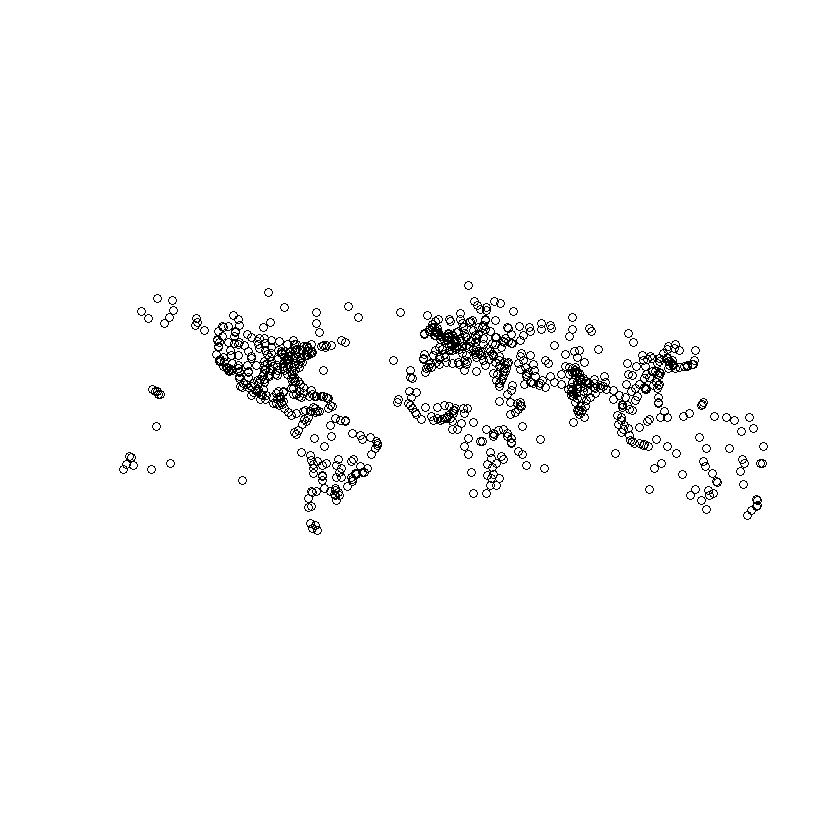

In [16]:
plot(st_geometry(airports))

The simple plot gives us a high-level view of our data.  The airports are represented globally using point markers.

Finally, let's export the *airports* object to our local machine the same way we did with the *usa_boundary* object.  Again, before we do this step, we will remove a memory-intensive feature column which would impede the export process.

In [17]:
# simplify the dataset by removing memory-intensive columns
airports <- airports[, !names(airports) %in% c("ne_id")]

st_write(airports, "airports.shp", driver = "ESRI Shapefile", delete_dsn = T)

Warning message in CPL_write_ogr(obj, dsn, layer, driver, as.character(dataset_options), :
"GDAL Error 1: airports.shp does not appear to be a file or directory."


Deleting source `airports.shp' failed
Writing layer `airports' to data source `airports.shp' using driver `ESRI Shapefile'
Writing 893 features with 39 fields and geometry type Point.


Warning message in CPL_write_ogr(obj, dsn, layer, driver, as.character(dataset_options), :
"GDAL Message 1: One or several characters couldn't be converted correctly from UTF-8 to ISO-8859-1.  This warning will not be emitted anymore."


### 3c. Global Time Zones

For a final exercise, we will extract and download the global time zone boundaries from the Natural Earth repository.

Taking a look at the lists of available data we identified in part 2, we can see that *time_zones* data is only available at the 1:10 (large) scale.

In [18]:
time_zones <- ne_download(scale = 10, type = "time_zones", category = "cultural", returnclass = "sf")

head(time_zones)

objectid,scalerank,featurecla,name,map_color6,map_color8,note,zone,utc_format,time_zone,iso_8601,places,dst_places,tz_name1st,tz_namesum,geometry
<int>,<int>,<chr>,<chr>,<int>,<int>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<MULTIPOLYGON [°]>
2,6,Timezone,-10,4,4,NA,-10,UTC-10:00,UTC-10:00,2012-05-30T18:33:50-10:00,Arctic Ocean,NA,NA,0,MULTIPOLYGON (((-142.4651 7...
2,6,Timezone,-10,4,4,NA,-10,UTC-10:00,UTC-10:00,2012-05-30T18:33:50-10:00,United States (Aleutian Islands),United States (Aleutian Islands),NA,0,MULTIPOLYGON (((179.9997 59...
1,6,Timezone,-11,5,3,NA,-11,UTC-11:00,UTC-11:00,2012-05-30T17:33:50-11:00,Arctic Ocean,NA,NA,0,MULTIPOLYGON (((-157.9421 7...
1,6,Timezone,-11,5,3,NA,-11,UTC-11:00,UTC-11:00,2012-05-30T17:33:50-11:00,"American Samoa, Niue",NA,NA,0,MULTIPOLYGON (((-172.483 15...
1,6,Timezone,-11,5,3,NA,-11,UTC-11:00,UTC-11:00,2012-05-30T17:33:50-11:00,"American Samoa, Niue",NA,Pacific/Midway,1,MULTIPOLYGON (((-172.5135 4...
1,6,Timezone,-11,5,3,NA,-11,UTC-11:00,UTC-11:00,2012-05-30T17:33:50-11:00,"American Samoa, Niue",NA,Pacific/Pago_Pago,2,MULTIPOLYGON (((-167.9977 -...


Extracting the *time_zones* data gives us an *sf* object with 120 polygon features, representing 120 time zones, and 15 attribute columns.  Attributes include informaiton such as time zone name, the [Universal Coordinated Time (UTC) format](https://en.wikipedia.org/wiki/Coordinated_Universal_Time) for the time zone, and a list of places in the time zone.

Let's take a look at a quick map of the *time_zones* data.

Warning message in st_is_longlat(x):
"bounding box has potentially an invalid value range for longlat data"


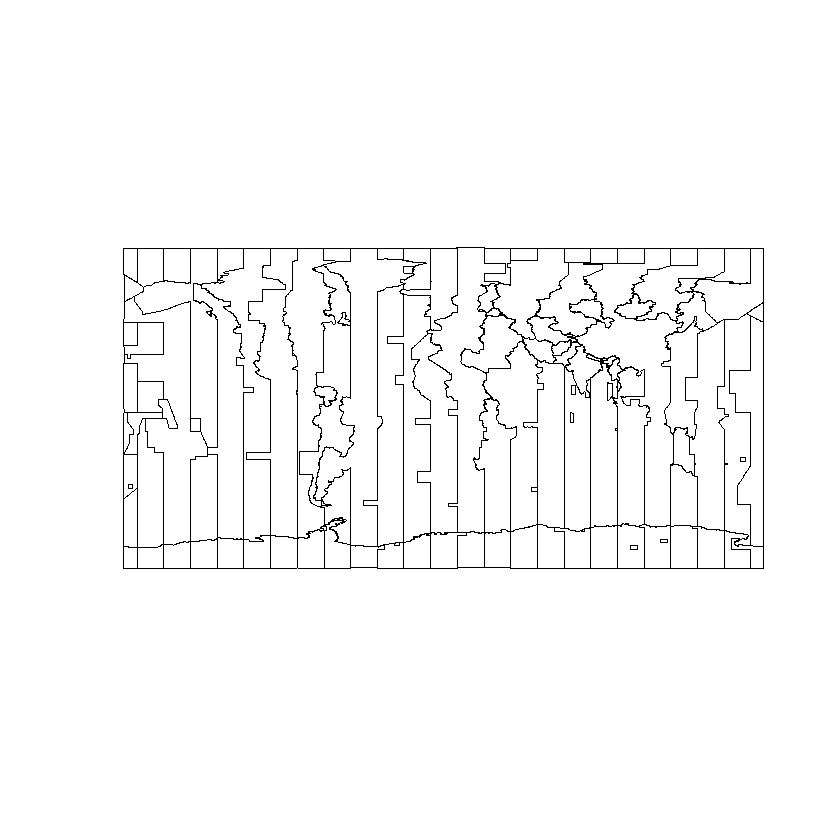

In [19]:
plot(st_geometry(time_zones))

Let's write the *time_zones* object as a shapefile to our local machine.

In [20]:
st_write(time_zones, "time_zones.shp", driver = "ESRI Shapefile", delete_dsn = T)

Warning message in CPL_write_ogr(obj, dsn, layer, driver, as.character(dataset_options), :
"GDAL Error 1: time_zones.shp does not appear to be a file or directory."


Deleting source `time_zones.shp' failed
Writing layer `time_zones' to data source 
  `time_zones.shp' using driver `ESRI Shapefile'
Writing 120 features with 15 fields and geometry type Multi Polygon.


At the end of this script we have explored the available data in the Natural Earth repository and extracted three spatial datasets representing the boundary of the United States, global airport point locations, and global time zone boundaries.